# Model Training — Employee Performance Prediction
**IABAC Certified Data Scientist — Project Code: 10281**

This notebook trains **two separate models**, because they serve two different, non-interchangeable
purposes:

1. **Hiring Model** — uses only features that are actually knowable about an external candidate
   at screening time. This is the model that fulfills the brief's requirement: *"A trained model
   which can predict the employee performance based on factors as inputs. This will be used to
   hire employees."* Using tenure/satisfaction/compensation-growth features here would be a
   feature-availability error — those values don't exist yet for someone who hasn't been hired.
2. **Diagnostic Model** — uses the full feature set, trained on the *current workforce*, to
   answer *"what drives performance among existing employees"* (the Top-3-Factors business
   question). This is a legitimate use of tenure/satisfaction data because it's about people who
   are already employed, not candidates.

Both models: benchmark 5 algorithms with 5-fold CV, apply **class weighting** to counter the
73% / 16% / 11% target imbalance, **select the best algorithm by CV macro-F1 (not single-split
test accuracy)**, then tune and persist the winner.


In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

df = pd.read_csv('../../data/processed/employee_performance_processed.csv')
hiring_safe_features = joblib.load('../../models/hiring_safe_features.pkl')
not_hiring_safe_features = joblib.load('../../models/not_hiring_safe_features.pkl')

print('Total rows:', df.shape[0])
print('Hiring-safe features:', len(hiring_safe_features))
print('Diagnostic-only extra features:', len(not_hiring_safe_features))

Total rows: 1200
Hiring-safe features: 12
Diagnostic-only extra features: 14


## Class Imbalance Check

In [2]:
y_full = df['PerformanceRating']
class_dist = y_full.value_counts(normalize=True).sort_index()
print('Class distribution:')
print((class_dist * 100).round(1))
print()
print('This is why every model below is trained with class weighting (`class_weight=\'balanced\'`')
print('for models that support it natively, and `sample_weight` computed the same way for')
print('Gradient Boosting / XGBoost, which do not expose a class_weight parameter).')

Class distribution:
PerformanceRating
2    16.2
3    72.8
4    11.0
Name: proportion, dtype: float64

This is why every model below is trained with class weighting (`class_weight='balanced'`
for models that support it natively, and `sample_weight` computed the same way for
Gradient Boosting / XGBoost, which do not expose a class_weight parameter).


## Reusable Training Function

Defined once, used identically for both the Hiring Model and the Diagnostic Model, so the two are directly comparable and neither gets special treatment.

In [3]:
def build_and_select_model(X, y, label, random_state=RANDOM_STATE):
    """Benchmarks 5 class-weighted algorithms with CV, selects the best by CV macro-F1
    (not single-split test accuracy), tunes it, and returns the fitted final model + report."""

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    y_train_xgb = y_train - y_train.min()
    y_test_xgb = y_test - y_train.min()
    sw_train = compute_sample_weight('balanced', y_train)

    candidates = {
        'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced'), True, False),
        'Support Vector Machine': (SVC(kernel='rbf', random_state=random_state, class_weight='balanced'), True, False),
        'Random Forest': (RandomForestClassifier(n_estimators=300, random_state=random_state, class_weight='balanced'), False, False),
        'Gradient Boosting': (GradientBoostingClassifier(random_state=random_state), False, True),
        'XGBoost': (XGBClassifier(random_state=random_state, eval_metric='mlogloss'), False, True),
    }

    rows = []
    for name, (model, needs_scaling, needs_sample_weight) in candidates.items():
        Xtr = X_train_scaled if needs_scaling else X_train
        Xte = X_test_scaled if needs_scaling else X_test
        ytr = y_train_xgb if name == 'XGBoost' else y_train
        yte = y_test_xgb if name == 'XGBoost' else y_test

        if needs_sample_weight:
            model.fit(Xtr, ytr, sample_weight=sw_train)
        else:
            model.fit(Xtr, ytr)

        preds = model.predict(Xte)
        acc = accuracy_score(yte, preds)
        f1_macro_holdout = f1_score(yte, preds, average='macro')

        # Selection criterion: CV macro-F1 on the TRAINING fold only (test set stays untouched)
        cv_f1 = cross_val_score(model, Xtr, ytr, cv=CV, scoring='f1_macro',
                                 params={'sample_weight': sw_train} if needs_sample_weight else None)
        cv_acc = cross_val_score(model, Xtr, ytr, cv=CV, scoring='accuracy',
                                  params={'sample_weight': sw_train} if needs_sample_weight else None)

        rows.append({
            'Model': name,
            'CV Macro-F1 (mean)': round(cv_f1.mean(), 4),
            'CV Macro-F1 (std)': round(cv_f1.std(), 4),
            'CV Accuracy (mean)': round(cv_acc.mean(), 4),
            'Holdout Test Accuracy': round(acc, 4),
            'Holdout Macro-F1': round(f1_macro_holdout, 4),
        })

    results_df = pd.DataFrame(rows).sort_values('CV Macro-F1 (mean)', ascending=False).reset_index(drop=True)
    best_name = results_df.iloc[0]['Model']

    print(f'=== {label}: baseline comparison (selected by CV Macro-F1, NOT holdout accuracy) ===')
    print(results_df.to_string(index=False))
    print(f'\nSelected: {best_name}')

    return {
        'best_name': best_name,
        'results_df': results_df,
        'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test,
        'X_train_scaled': X_train_scaled, 'X_test_scaled': X_test_scaled,
        'scaler': scaler, 'sw_train': sw_train,
        'y_train_xgb': y_train_xgb, 'y_test_xgb': y_test_xgb,
        'label_offset': y_train.min(),
    }

## Tuning Function

In [4]:
param_grids = {
    'Logistic Regression': {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']},
    'Support Vector Machine': {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto']},
    'Random Forest': {'n_estimators': [200, 300, 500], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2, 4]},
    'Gradient Boosting': {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, 4]},
    'XGBoost': {'n_estimators': [100, 200], 'max_depth': [3, 4, 6], 'learning_rate': [0.05, 0.1]},
}
needs_scaling_map = {'Logistic Regression': True, 'Support Vector Machine': True,
                      'Random Forest': False, 'Gradient Boosting': False, 'XGBoost': False}
needs_sample_weight_map = {'Logistic Regression': False, 'Support Vector Machine': False,
                            'Random Forest': False, 'Gradient Boosting': True, 'XGBoost': True}

def tune_and_finalize(bundle, feature_columns, label):
    best_name = bundle['best_name']
    needs_scaling = needs_scaling_map[best_name]
    needs_sw = needs_sample_weight_map[best_name]

    Xtr = bundle['X_train_scaled'] if needs_scaling else bundle['X_train']
    Xte = bundle['X_test_scaled'] if needs_scaling else bundle['X_test']
    ytr = bundle['y_train_xgb'] if best_name == 'XGBoost' else bundle['y_train']
    yte = bundle['y_test_xgb'] if best_name == 'XGBoost' else bundle['y_test']
    sw = bundle['sw_train']

    base_kwargs = {'random_state': RANDOM_STATE}
    if best_name == 'XGBoost':
        base_kwargs['eval_metric'] = 'mlogloss'
    if best_name == 'Logistic Regression':
        base_kwargs['max_iter'] = 1000
    if best_name in ('Logistic Regression', 'Support Vector Machine', 'Random Forest'):
        base_kwargs['class_weight'] = 'balanced'

    base_estimator_cls = {
        'Logistic Regression': LogisticRegression, 'Support Vector Machine': SVC,
        'Random Forest': RandomForestClassifier, 'Gradient Boosting': GradientBoostingClassifier,
        'XGBoost': XGBClassifier,
    }[best_name]
    base_estimator = base_estimator_cls(**base_kwargs)

    fit_params = {'sample_weight': sw} if needs_sw else {}
    grid = GridSearchCV(base_estimator, param_grids[best_name], cv=CV, scoring='f1_macro', n_jobs=-1)
    grid.fit(Xtr, ytr, **fit_params)

    final_model = grid.best_estimator_
    final_preds = final_model.predict(Xte)
    final_acc = accuracy_score(yte, final_preds)
    final_f1 = f1_score(yte, final_preds, average='macro')

    print(f'=== {label}: tuned {best_name} ===')
    print('Best params:', grid.best_params_)
    print('Best CV macro-F1:', round(grid.best_score_, 4))
    print('Holdout test accuracy:', round(final_acc, 4))
    print('Holdout macro-F1:', round(final_f1, 4))

    label_offset = bundle['label_offset'] if best_name == 'XGBoost' else 0
    true_labels = yte + label_offset
    pred_labels = final_preds + label_offset
    print()
    print(classification_report(true_labels, pred_labels))

    return {
        'model': final_model, 'model_name': best_name, 'needs_scaling': needs_scaling,
        'scaler': bundle['scaler'], 'label_offset': int(label_offset),
        'test_accuracy': float(final_acc), 'macro_f1': float(final_f1),
        'cv_macro_f1': float(grid.best_score_), 'best_params': grid.best_params_,
        'feature_columns': feature_columns, 'true_labels': true_labels, 'pred_labels': pred_labels,
    }

## 1. Hiring Model (candidate-screening-safe features only)

In [5]:
X_hiring = df[hiring_safe_features]
y = df['PerformanceRating']

hiring_bundle = build_and_select_model(X_hiring, y, label='HIRING MODEL')

=== HIRING MODEL: baseline comparison (selected by CV Macro-F1, NOT holdout accuracy) ===
                 Model  CV Macro-F1 (mean)  CV Macro-F1 (std)  CV Accuracy (mean)  Holdout Test Accuracy  Holdout Macro-F1
               XGBoost              0.3491             0.0235              0.6302                 0.6000            0.3359
     Gradient Boosting              0.3201             0.0354              0.4625                 0.4917            0.3769
   Logistic Regression              0.2993             0.0101              0.3375                 0.2958            0.2644
Support Vector Machine              0.2980             0.0288              0.3792                 0.4083            0.3218
         Random Forest              0.2937             0.0127              0.7198                 0.7208            0.2806

Selected: XGBoost


In [6]:
hiring_final = tune_and_finalize(hiring_bundle, hiring_safe_features, label='HIRING MODEL')

=== HIRING MODEL: tuned XGBoost ===
Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV macro-F1: 0.3693
Holdout test accuracy: 0.4167
Holdout macro-F1: 0.3309

              precision    recall  f1-score   support

           2       0.22      0.64      0.33        39
           3       0.83      0.41      0.54       175
           4       0.10      0.15      0.12        26

    accuracy                           0.42       240
   macro avg       0.38      0.40      0.33       240
weighted avg       0.65      0.42      0.46       240



### Honest Reality Check: Majority-Class Baseline

Because the target is imbalanced (~73% Rating 3), a naive model that always predicts the
majority class would score close to 73% *accuracy* — but 0% recall on Ratings 2 and 4, so its
macro-F1 would be low. This baseline is computed below and compared against the Hiring Model to
make sure its modest numbers are read in the right context: the drop from the (feature-leaking)
first-draft model's 93%+ accuracy down to ~42% here is not a bug — it is the honest cost of
removing information that a real candidate's file would never contain.

In [7]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(hiring_bundle['X_train'], hiring_bundle['y_train'])
dummy_preds = dummy.predict(hiring_bundle['X_test'])
dummy_acc = accuracy_score(hiring_bundle['y_test'], dummy_preds)
dummy_f1 = f1_score(hiring_bundle['y_test'], dummy_preds, average='macro')

print('Majority-class baseline  -> accuracy:', round(dummy_acc, 4), '| macro-F1:', round(dummy_f1, 4))
print('Hiring Model (tuned)     -> accuracy:', round(hiring_final['test_accuracy'], 4), '| macro-F1:', round(hiring_final['macro_f1'], 4))
print()
print('The Hiring Model trades raw accuracy for balanced performance across all three rating')
print('classes (that is what class-weighting + macro-F1 selection optimizes for) — it correctly')
print('identifies some Rating-2 and Rating-4 candidates that the majority-class baseline would')
print('always miss, at the cost of getting fewer Rating-3 predictions right. Its macro-F1')
print(f"({hiring_final['macro_f1']:.3f}) beats the baseline's ({dummy_f1:.3f}), even though its")
print('raw accuracy is lower than always guessing the majority class.')

Majority-class baseline  -> accuracy: 0.7292 | macro-F1: 0.2811
Hiring Model (tuned)     -> accuracy: 0.4167 | macro-F1: 0.3309

The Hiring Model trades raw accuracy for balanced performance across all three rating
classes (that is what class-weighting + macro-F1 selection optimizes for) — it correctly
identifies some Rating-2 and Rating-4 candidates that the majority-class baseline would
always miss, at the cost of getting fewer Rating-3 predictions right. Its macro-F1
(0.331) beats the baseline's (0.281), even though its
raw accuracy is lower than always guessing the majority class.


## 2. Diagnostic Model (full feature set, current workforce)

In [8]:
X_diag = df.drop(columns=['PerformanceRating'])
diag_feature_cols = list(X_diag.columns)

diag_bundle = build_and_select_model(X_diag, y, label='DIAGNOSTIC MODEL')

=== DIAGNOSTIC MODEL: baseline comparison (selected by CV Macro-F1, NOT holdout accuracy) ===
                 Model  CV Macro-F1 (mean)  CV Macro-F1 (std)  CV Accuracy (mean)  Holdout Test Accuracy  Holdout Macro-F1
         Random Forest              0.8915             0.0103              0.9323                 0.9375            0.8983
               XGBoost              0.8860             0.0132              0.9240                 0.9167            0.8692
     Gradient Boosting              0.8710             0.0173              0.9125                 0.9167            0.8719
Support Vector Machine              0.6966             0.0224              0.7667                 0.7500            0.6794
   Logistic Regression              0.6431             0.0360              0.7042                 0.7333            0.6662

Selected: Random Forest


In [9]:
diag_final = tune_and_finalize(diag_bundle, diag_feature_cols, label='DIAGNOSTIC MODEL')

=== DIAGNOSTIC MODEL: tuned Random Forest ===
Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'n_estimators': 300}
Best CV macro-F1: 0.8957
Holdout test accuracy: 0.9417
Holdout macro-F1: 0.901

              precision    recall  f1-score   support

           2       0.92      0.87      0.89        39
           3       0.94      0.99      0.96       175
           4       1.00      0.73      0.84        26

    accuracy                           0.94       240
   macro avg       0.95      0.86      0.90       240
weighted avg       0.94      0.94      0.94       240



## 3. Confusion Matrices

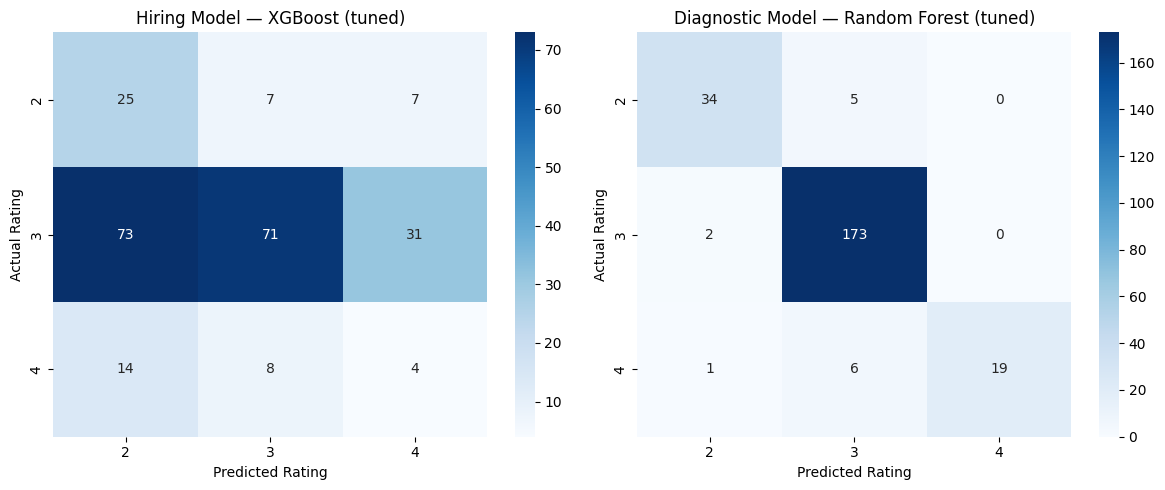

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))
for ax, final, title in [(axes[0], hiring_final, 'Hiring Model'), (axes[1], diag_final, 'Diagnostic Model')]:
    cm = confusion_matrix(final['true_labels'], final['pred_labels'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
    ax.set_xlabel('Predicted Rating')
    ax.set_ylabel('Actual Rating')
    ax.set_title(f"{title} — {final['model_name']} (tuned)")
plt.tight_layout()
plt.savefig('../../references/confusion_matrix.png', dpi=120)
plt.show()

## 4. Feature Importance — Both Models

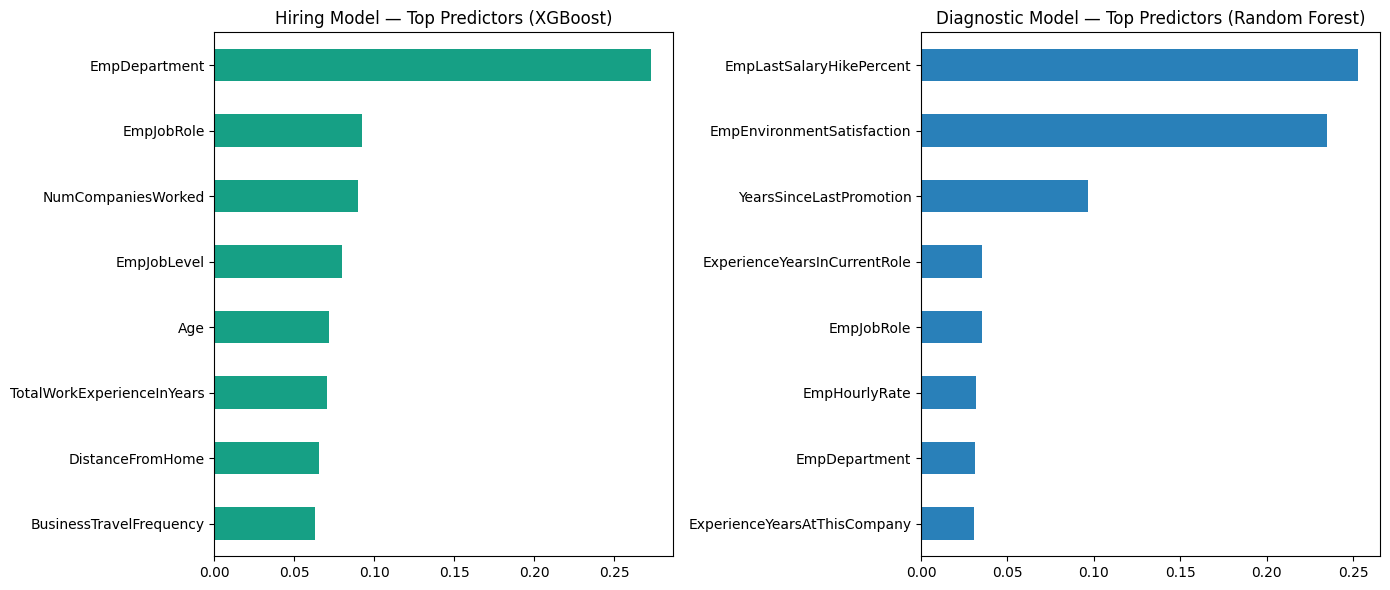

HIRING MODEL — top predictors usable at candidate screening time:
EmpDepartment         0.2734
EmpJobRole            0.0922
NumCompaniesWorked    0.0896
EmpJobLevel           0.0797
Age                   0.0719
dtype: float32

DIAGNOSTIC MODEL — top 3 factors affecting performance (current workforce):
1. EmpLastSalaryHikePercent (importance: 0.2530)
2. EmpEnvironmentSatisfaction (importance: 0.2349)
3. YearsSinceLastPromotion (importance: 0.0965)


In [11]:
def get_importances(final, X_input_for_permutation, y_input_for_permutation):
    model = final['model']
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=final['feature_columns']).sort_values(ascending=False)
    elif hasattr(model, 'coef_'):
        return pd.Series(np.abs(model.coef_).mean(axis=0), index=final['feature_columns']).sort_values(ascending=False)
    else:
        from sklearn.inspection import permutation_importance
        perm = permutation_importance(model, X_input_for_permutation, y_input_for_permutation, n_repeats=15, random_state=RANDOM_STATE)
        return pd.Series(perm.importances_mean, index=final['feature_columns']).sort_values(ascending=False)

hiring_Xte = hiring_bundle['X_test_scaled'] if hiring_final['needs_scaling'] else hiring_bundle['X_test']
hiring_yte = hiring_bundle['y_test_xgb'] if hiring_final['model_name']=='XGBoost' else hiring_bundle['y_test']
hiring_importances = get_importances(hiring_final, hiring_Xte, hiring_yte)

diag_Xte = diag_bundle['X_test_scaled'] if diag_final['needs_scaling'] else diag_bundle['X_test']
diag_yte = diag_bundle['y_test_xgb'] if diag_final['model_name']=='XGBoost' else diag_bundle['y_test']
diag_importances = get_importances(diag_final, diag_Xte, diag_yte)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
hiring_importances.head(8).sort_values().plot(kind='barh', ax=axes[0], color='#16a085')
axes[0].set_title(f"Hiring Model — Top Predictors ({hiring_final['model_name']})")
diag_importances.head(8).sort_values().plot(kind='barh', ax=axes[1], color='#2980b9')
axes[1].set_title(f"Diagnostic Model — Top Predictors ({diag_final['model_name']})")
plt.tight_layout()
plt.savefig('../../references/feature_importance.png', dpi=120)
plt.show()

print('HIRING MODEL — top predictors usable at candidate screening time:')
print(hiring_importances.head(5).round(4))
print()
print('DIAGNOSTIC MODEL — top 3 factors affecting performance (current workforce):')
diag_top3 = diag_importances.head(3)
for i, (feat, score) in enumerate(diag_top3.items(), 1):
    print(f'{i}. {feat} (importance: {score:.4f})')

## 5. Save Both Models

In [12]:
os.makedirs('../../models', exist_ok=True)

# Hiring model artifacts
joblib.dump(hiring_final['model'], '../../models/hiring_model.pkl')
joblib.dump(hiring_final['scaler'], '../../models/hiring_scaler.pkl')
joblib.dump(hiring_final['feature_columns'], '../../models/hiring_feature_names.pkl')

# Diagnostic model artifacts
joblib.dump(diag_final['model'], '../../models/diagnostic_model.pkl')
joblib.dump(diag_final['scaler'], '../../models/diagnostic_scaler.pkl')
joblib.dump(diag_final['feature_columns'], '../../models/diagnostic_feature_names.pkl')

metadata = {
    'hiring_model': {
        'model_name': hiring_final['model_name'],
        'needs_scaling': hiring_final['needs_scaling'],
        'label_offset': hiring_final['label_offset'],
        'test_accuracy': hiring_final['test_accuracy'],
        'macro_f1': hiring_final['macro_f1'],
        'cv_macro_f1': hiring_final['cv_macro_f1'],
        'best_params': hiring_final['best_params'],
        'feature_columns': hiring_final['feature_columns'],
        'top_predictors': list(hiring_importances.head(3).index),
        'selection_criterion': 'CV macro-F1 (5-fold, stratified)',
        'class_weighting': 'balanced (native class_weight or compute_sample_weight)',
    },
    'diagnostic_model': {
        'model_name': diag_final['model_name'],
        'needs_scaling': diag_final['needs_scaling'],
        'label_offset': diag_final['label_offset'],
        'test_accuracy': diag_final['test_accuracy'],
        'macro_f1': diag_final['macro_f1'],
        'cv_macro_f1': diag_final['cv_macro_f1'],
        'best_params': diag_final['best_params'],
        'feature_columns': diag_final['feature_columns'],
        'top_3_factors': list(diag_top3.index),
        'selection_criterion': 'CV macro-F1 (5-fold, stratified)',
        'class_weighting': 'balanced (native class_weight or compute_sample_weight)',
    },
}
with open('../../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:')
print('  models/hiring_model.pkl, hiring_scaler.pkl, hiring_feature_names.pkl')
print('  models/diagnostic_model.pkl, diagnostic_scaler.pkl, diagnostic_feature_names.pkl')
print('  models/model_metadata.json (both models\' metadata)')
print()
print(json.dumps(metadata, indent=2))

Saved:
  models/hiring_model.pkl, hiring_scaler.pkl, hiring_feature_names.pkl
  models/diagnostic_model.pkl, diagnostic_scaler.pkl, diagnostic_feature_names.pkl
  models/model_metadata.json (both models' metadata)

{
  "hiring_model": {
    "model_name": "XGBoost",
    "needs_scaling": false,
    "label_offset": 2,
    "test_accuracy": 0.4166666666666667,
    "macro_f1": 0.3309447297733638,
    "cv_macro_f1": 0.3693237619690999,
    "best_params": {
      "learning_rate": 0.05,
      "max_depth": 3,
      "n_estimators": 100
    },
    "feature_columns": [
      "Age",
      "Gender",
      "EducationBackground",
      "MaritalStatus",
      "EmpDepartment",
      "EmpJobRole",
      "EmpJobLevel",
      "BusinessTravelFrequency",
      "DistanceFromHome",
      "EmpEducationLevel",
      "NumCompaniesWorked",
      "TotalWorkExperienceInYears"
    ],
    "top_predictors": [
      "EmpDepartment",
      "EmpJobRole",
      "NumCompaniesWorked"
    ],
    "selection_criterion": "CV macr

## Summary

- **Two models were trained**, not one, because the project's two asks (hiring prediction vs.
  identifying performance drivers) require different, non-overlapping feature sets — using the
  same blended model for both was the core issue corrected in this revision.
- **Hiring Model** uses only candidate-screening-safe features; its algorithm and metrics are
  printed under Section 1 above.
- **Diagnostic Model** uses the full feature set on the current workforce; its metrics and the
  resulting **Top 3 Factors** are printed under Section 2 and 4 above.
- Both models used **class-weighted training** (`class_weight='balanced'` or an equivalent
  `sample_weight`) to counter the 73%/16%/11% target imbalance, and were **selected by 5-fold CV
  macro-F1**, not single-split holdout accuracy — the holdout test set is reported only as a
  final, previously-unseen confirmation, never as the selection criterion.
- Exact numbers for both models are in `models/model_metadata.json` and reproduced in
  `predict_model.ipynb`.
